# 11. Interpretabilidad de Modelos 🔬

Este notebook explora técnicas modernas de interpretabilidad de modelos, incluyendo SHAP, LIME e importancia de características.

✨ **Highlights:**
- Feature Importance global con Random Forest
- SHAP: explicaciones globales (summary plot) y locales (force + dependence plot)
- LIME: explicación local agnóstica al modelo
- Explicabilidad de redes neuronales con SHAP KernelExplainer y LIME
- Comparación RF vs MLP: features más influyentes y tiempos de cómputo

## Objetivo
- Comprender la importancia de la interpretabilidad en ML.
- Implementar y visualizar SHAP, LIME e importancia de características.
- Aprender a comunicar resultados de interpretabilidad.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [01](./01_intro_machine_learning.ipynb) y [03](./03_modelos_clasicos_ml.ipynb).

- Conceptos de modelos de clasificación, Random Forest, y métricas.

> ⚠️ **Dependencias adicionales:** `pip install shap lime`

## 1. Introducción teórica

La interpretabilidad permite entender **por qué** un modelo toma ciertas decisiones. Esto es esencial para:
- Validar y confiar en modelos antes de desplegarlos.
- Detectar sesgos y problemas en los datos.
- Cumplir con regulaciones (GDPR, IA responsable).

| Técnica | Alcance | Ventaja | Desventaja |
|---------|---------|---------|------------|
| **Feature Importance** | Global | Rápido, integrado en el modelo | Solo modelos de árboles |
| **SHAP** | Global + Local | Robusto, basado en teoría de juegos | Más costoso computacionalmente |
| **LIME** | Local | Rápido, agnóstico al modelo | Aproximación local, puede variar |

## 2. Importación de librerías

In [1]:
import random
import numpy as np
import time
from importlib.metadata import version as pkg_version

# === Reproducibilidad ===
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Importar SHAP y LIME con manejo de errores
try:
    import shap
    print(f'SHAP {shap.__version__} ✅')
except ImportError:
    raise ImportError('Instala SHAP: pip install shap')

try:
    import lime
    import lime.lime_tabular
    print(f'LIME {pkg_version("lime")} ✅')
except ImportError:
    raise ImportError('Instala LIME: pip install lime')

print('\nLibrerías cargadas ✅')

SHAP 0.51.0 ✅
LIME 0.2.0.1 ✅

Librerías cargadas ✅


## 3. Entrenar un modelo de ejemplo

In [2]:
data = load_breast_cancer()
features = data.feature_names
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

model = RandomForestClassifier(n_estimators=100, random_state=SEED)
model.fit(X_train, y_train)
print(f"Accuracy en test: {model.score(X_test, y_test):.2f}")

Accuracy en test: 0.96


## 4. Importancia de características

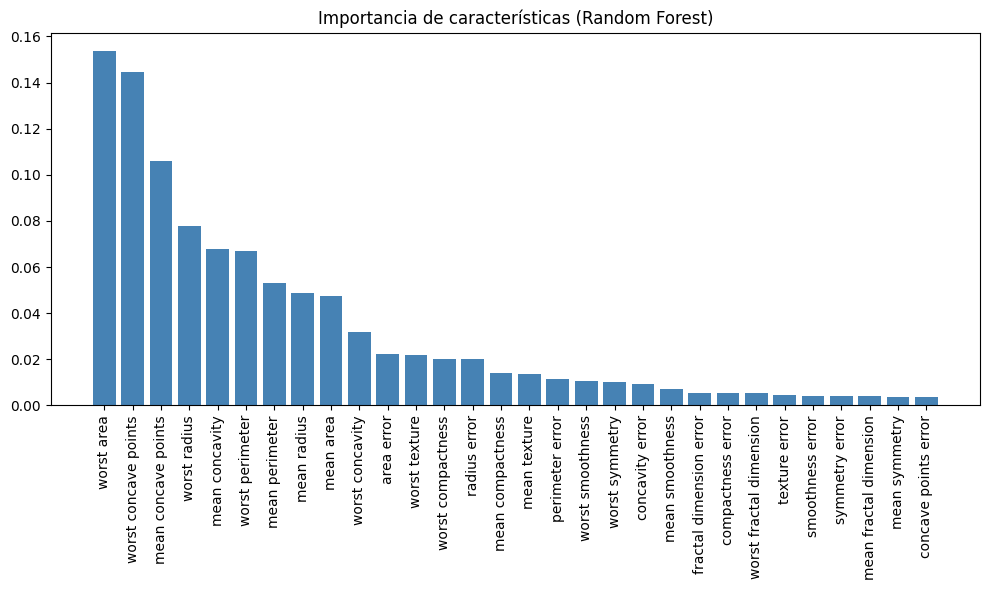

Top 5 variables más importantes:
  1. worst area: 0.1539
  2. worst concave points: 0.1447
  3. mean concave points: 0.1062
  4. worst radius: 0.0780
  5. mean concavity: 0.0680


In [3]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices], color='steelblue')
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.title('Importancia de características (Random Forest)')
plt.tight_layout()
plt.show()

# Top 5
print('Top 5 variables más importantes:')
for i in range(5):
    print(f'  {i+1}. {features[indices[i]]}: {importances[indices[i]]:.4f}')

## 5. Explicaciones con SHAP

⏱  Calculando valores SHAP...
   SHAP completado en 0.03s


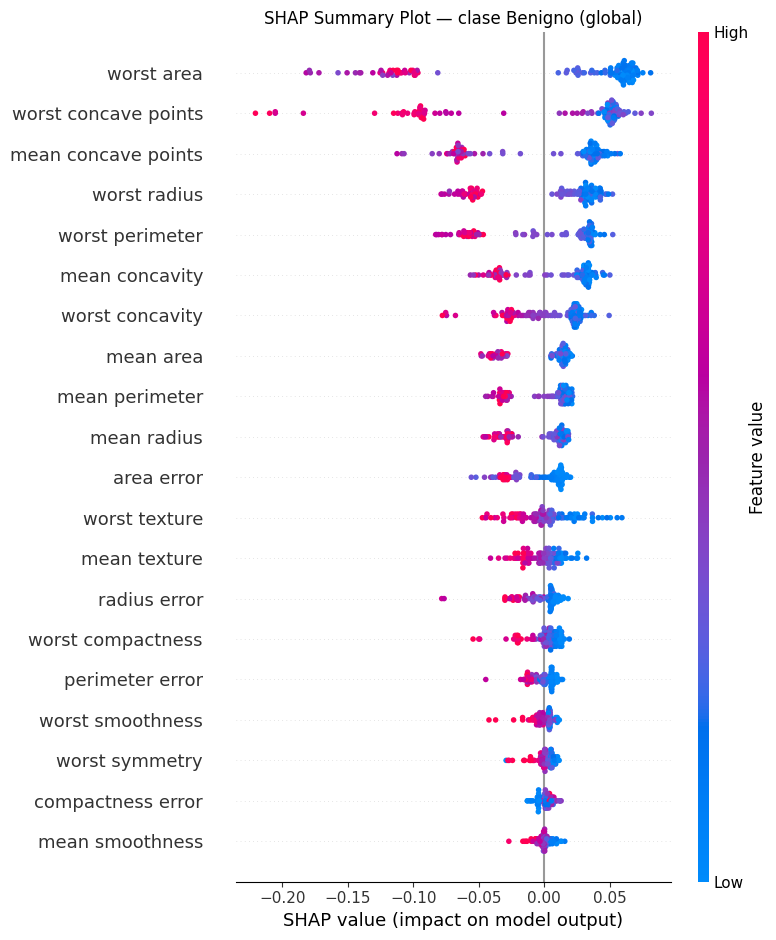

In [4]:
print('⏱  Calculando valores SHAP...')
start_shap = time.time()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
t_shap = time.time() - start_shap
print(f'   SHAP completado en {t_shap:.2f}s')

# SHAP >= 0.46 devuelve ndarray 3D (n_samples, n_features, n_classes)
# SHAP < 0.46  devuelve lista [array_clase0, array_clase1]
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv1 = shap_values[:, :, 1]        # (n_samples, n_features) — clase Benigno
    ev1 = float(explainer.expected_value[1])
else:
    sv1 = shap_values[1]
    ev1 = float(explainer.expected_value[1]) if hasattr(explainer.expected_value, '__len__') else float(explainer.expected_value)

# Summary plot global (importancia + dirección del efecto)
shap.summary_plot(sv1, X_test, feature_names=features, show=False)
plt.title('SHAP Summary Plot — clase Benigno (global)')
plt.tight_layout()
plt.show()

Explicación local SHAP — muestra 0 del conjunto de test:
  Predicción: Benigno (prob. benigno: 0.970)


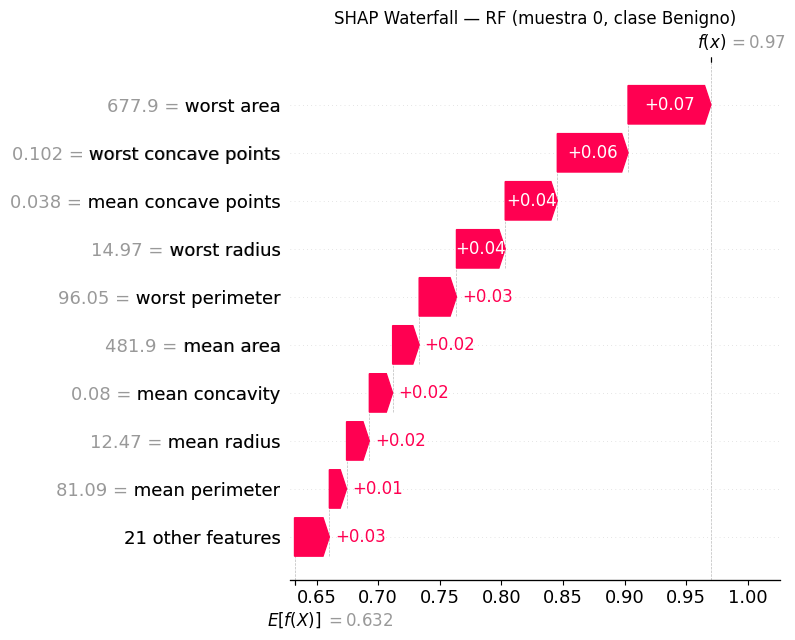

💡 Rojo = empuja hacia Benigno | Azul = empuja hacia Maligno
   f(x) = predicción final | E[f(x)] = valor esperado (base)

📊 SHAP Dependence Plot — feature más influyente: worst area


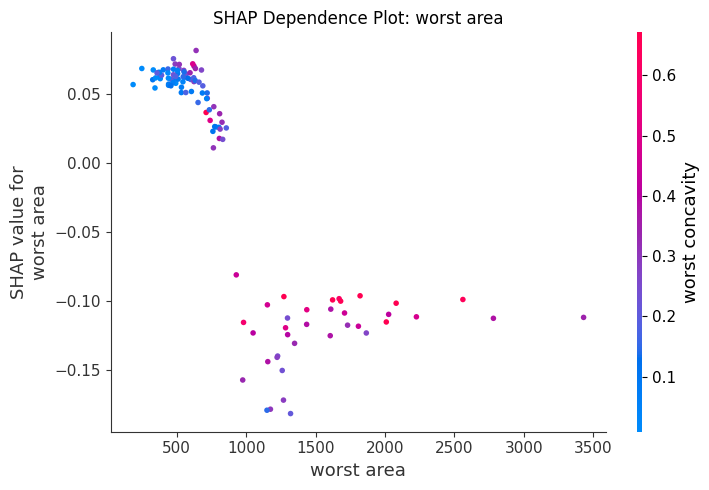

💡 Eje Y = contribución SHAP; eje X = valor de la feature.


In [5]:
# Explicación local — muestra 0
print('Explicación local SHAP — muestra 0 del conjunto de test:')
pred_class = model.predict(X_test[0:1])[0]
pred_proba = model.predict_proba(X_test[0:1])[0]
print(f'  Predicción: {"Benigno" if pred_class == 1 else "Maligno"} '
      f'(prob. benigno: {pred_proba[1]:.3f})')

# Waterfall plot: mucho más legible que force_plot en notebooks estáticos
# Muestra cada feature como barra horizontal con su contribución SHAP exacta
expl_local = shap.Explanation(
    values=sv1[0],
    base_values=ev1,
    data=X_test[0],
    feature_names=list(features)
)
plt.figure()
shap.plots.waterfall(expl_local, show=False)
plt.title('SHAP Waterfall — RF (muestra 0, clase Benigno)')
plt.tight_layout()
plt.show()
print('💡 Rojo = empuja hacia Benigno | Azul = empuja hacia Maligno')
print('   f(x) = predicción final | E[f(x)] = valor esperado (base)')

# Dependence plot: cómo afecta la feature más importante a la predicción
top_feature_idx = np.abs(sv1).mean(0).argmax()
top_feature = features[top_feature_idx]
print(f'\n📊 SHAP Dependence Plot — feature más influyente: {top_feature}')
shap.dependence_plot(
    top_feature_idx, sv1, X_test,
    feature_names=features, show=False)
plt.title(f'SHAP Dependence Plot: {top_feature}')
plt.tight_layout()
plt.show()
print('💡 Eje Y = contribución SHAP; eje X = valor de la feature.')

## 6. Explicaciones con LIME

⏱  Calculando explicación LIME...
   LIME completado en 0.0794s


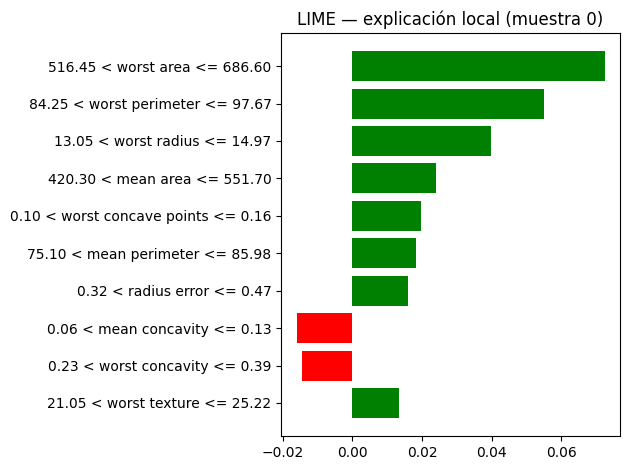


⏱  Comparación de tiempos de cómputo:
   SHAP (todo el test set):  0.03s  → 0.28 ms/muestra
   LIME (1 muestra):         0.0794s  → 79.36 ms/muestra

💡 SHAP TreeExplainer es rápido para árboles. Para redes neuronales usa shap.DeepExplainer o shap.KernelExplainer (más lento).


In [6]:
print('⏱  Calculando explicación LIME...')
start_lime = time.time()

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=features,
    class_names=['Maligno', 'Benigno'],
    discretize_continuous=True,
    random_state=SEED)

exp = explainer_lime.explain_instance(
    X_test[0], model.predict_proba, num_features=10)

t_lime = time.time() - start_lime
print(f'   LIME completado en {t_lime:.4f}s')

# Visualizar como gráfico (compatible con notebooks estáticos)
fig = exp.as_pyplot_figure()
plt.title('LIME — explicación local (muestra 0)')
plt.tight_layout()
plt.show()

# Comparación de tiempos
print(f'\n⏱  Comparación de tiempos de cómputo:')
print(f'   SHAP (todo el test set):  {t_shap:.2f}s  → {t_shap/len(X_test)*1000:.2f} ms/muestra')
print(f'   LIME (1 muestra):         {t_lime:.4f}s  → {t_lime*1000:.2f} ms/muestra')
print('\n💡 SHAP TreeExplainer es rápido para árboles. '
      'Para redes neuronales usa shap.DeepExplainer o shap.KernelExplainer (más lento).')

## 7. Explicabilidad de Redes Neuronales

Las redes neuronales son **cajas negras** sin interpretabilidad nativa. Se requieren métodos externos:

| Método | Compatibilidad | Velocidad | Notas |
|--------|---------------|-----------|-------|
| **SHAP TreeExplainer** | Solo árboles | Muy rápido | No aplica a redes |
| **SHAP KernelExplainer** | Cualquier modelo | Lento | Universal, basado en Shapley |
| **SHAP GradientExplainer** | TF / PyTorch | Rápido | Requiere acceso a gradientes |
| **LIME** | Cualquier modelo | Medio | Aproximación lineal local |

En esta sección entrenamos un MLP sobre el mismo dataset y lo explicamos con **KernelExplainer** y **LIME**, comparando las features más influyentes contra el Random Forest.

In [7]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

# Normalizar (redes neuronales son sensibles a la escala)
scaler_nn = StandardScaler()
X_train_nn = scaler_nn.fit_transform(X_train)
X_test_nn  = scaler_nn.transform(X_test)

# MLP simple para clasificación binaria
nn_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_nn.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

es_nn = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
nn_model.fit(X_train_nn, y_train, epochs=50, batch_size=32,
             validation_split=0.2, callbacks=[es_nn], verbose=0)

_, acc_nn = nn_model.evaluate(X_test_nn, y_test, verbose=0)
print(f'✅ Accuracy MLP:           {acc_nn:.4f}')
print(f'✅ Accuracy Random Forest: {model.score(X_test, y_test):.4f}')
nn_model.summary()

✅ Accuracy MLP:           0.9912
✅ Accuracy Random Forest: 0.9649


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,293 (48.02 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,196 (32.02 KB)

⏱  Calculando SHAP con KernelExplainer (agnóstico al modelo)...
   Background: 10 centroides K-Means del train | Evaluando primeras 20 muestras test


  0%|          | 0/20 [00:00<?, ?it/s]

   KernelExplainer completado en 9.0s


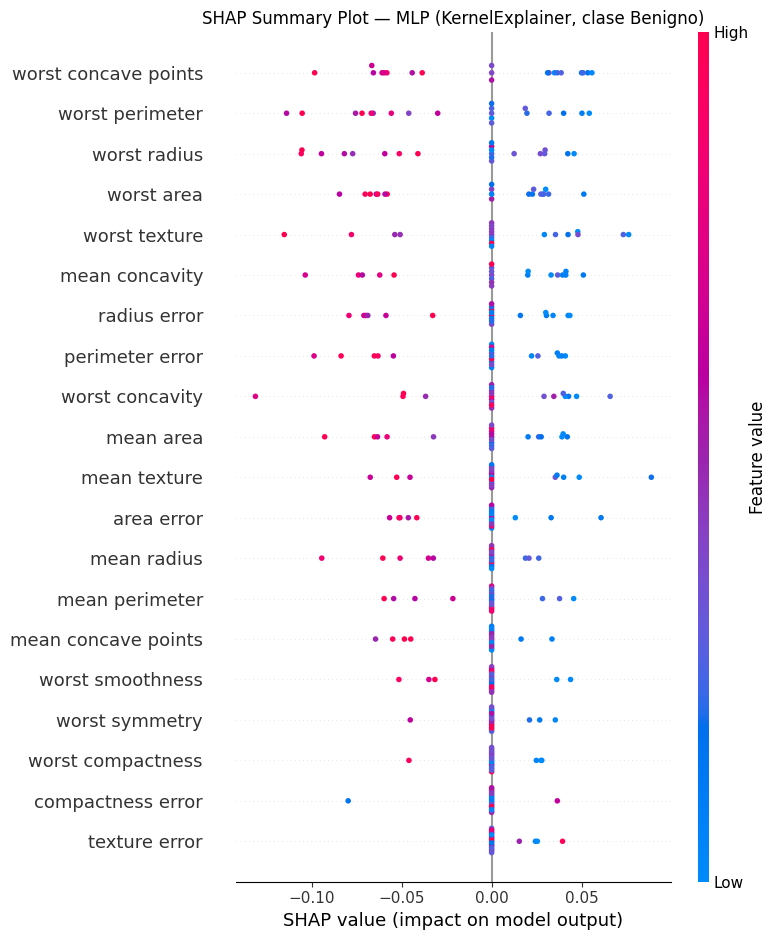

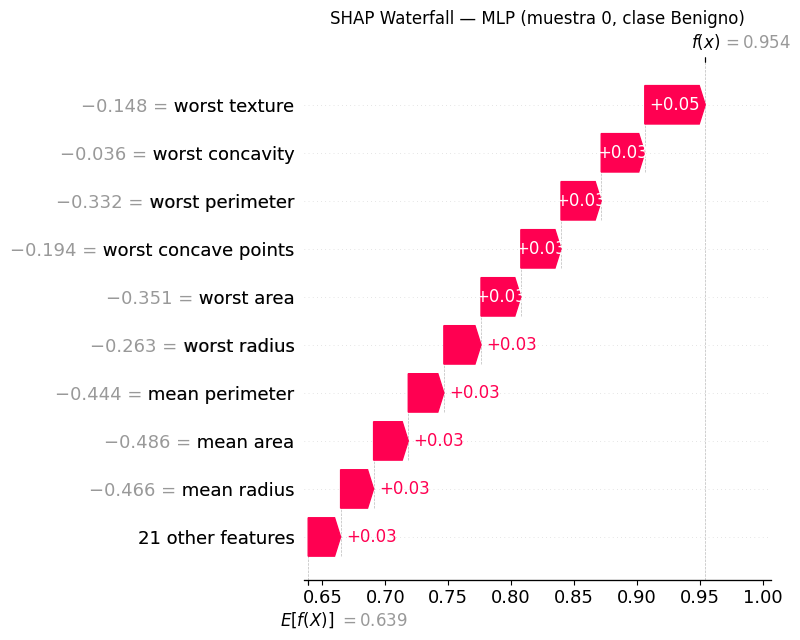


💡 KernelExplainer tardó 9.0s en 20 muestras.
   shap.GradientExplainer es ~10× más rápido para modelos TF/Keras con acceso a gradientes.


In [8]:
def nn_proba(x):
    """Wrapper: devuelve [P(Maligno), P(Benigno)] — formato requerido por SHAP/LIME."""
    p = nn_model.predict(x, verbose=0).flatten()
    return np.column_stack([1 - p, p])

print('⏱  Calculando SHAP con KernelExplainer (agnóstico al modelo)...')
print('   Background: 10 centroides K-Means del train | Evaluando primeras 20 muestras test')
background = shap.kmeans(X_train_nn, 10)
start_ke = time.time()
ke = shap.KernelExplainer(nn_proba, background)
shap_vals_nn = ke.shap_values(X_test_nn[:20], nsamples=200)
t_ke = time.time() - start_ke
print(f'   KernelExplainer completado en {t_ke:.1f}s')

# shap_vals_nn puede ser lista [clase0, clase1] o ndarray 3D
if isinstance(shap_vals_nn, list):
    sv_nn1 = shap_vals_nn[1]
else:
    sv_nn1 = shap_vals_nn[:, :, 1]

# Summary plot global
shap.summary_plot(sv_nn1, X_test_nn[:20], feature_names=features, show=False)
plt.title('SHAP Summary Plot — MLP (KernelExplainer, clase Benigno)')
plt.tight_layout()
plt.show()

# Waterfall plot local — muestra 0
expl_nn_local = shap.Explanation(
    values=sv_nn1[0],
    base_values=float(ke.expected_value[1]),
    data=X_test_nn[0],
    feature_names=list(features)
)
plt.figure()
shap.plots.waterfall(expl_nn_local, show=False)
plt.title('SHAP Waterfall — MLP (muestra 0, clase Benigno)')
plt.tight_layout()
plt.show()

print(f'\n💡 KernelExplainer tardó {t_ke:.1f}s en 20 muestras.')
print('   shap.GradientExplainer es ~10× más rápido para modelos TF/Keras con acceso a gradientes.')

⏱  Calculando LIME para la red neuronal...
   LIME MLP completado en 1.1712s


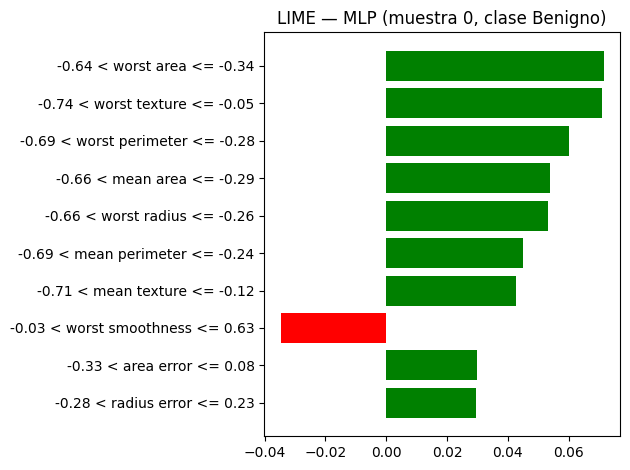


⏱  Resumen de tiempos (explicabilidad):
   SHAP TreeExplainer RF (114 muestras): 0.03s
   SHAP KernelExplainer MLP (20 muestras):        9.0s
   LIME RF (1 muestra):                           0.0794s
   LIME MLP (1 muestra):                          1.1712s


In [9]:
print('⏱  Calculando LIME para la red neuronal...')
explainer_lime_nn = lime.lime_tabular.LimeTabularExplainer(
    X_train_nn,
    feature_names=features,
    class_names=['Maligno', 'Benigno'],
    discretize_continuous=True,
    random_state=SEED)

start_lime_nn = time.time()
exp_nn = explainer_lime_nn.explain_instance(X_test_nn[0], nn_proba, num_features=10)
t_lime_nn = time.time() - start_lime_nn
print(f'   LIME MLP completado en {t_lime_nn:.4f}s')

fig = exp_nn.as_pyplot_figure()
plt.title('LIME — MLP (muestra 0, clase Benigno)')
plt.tight_layout()
plt.show()

print(f'\n⏱  Resumen de tiempos (explicabilidad):')
print(f'   SHAP TreeExplainer RF ({len(X_test)} muestras): {t_shap:.2f}s')
print(f'   SHAP KernelExplainer MLP (20 muestras):        {t_ke:.1f}s')
print(f'   LIME RF (1 muestra):                           {t_lime:.4f}s')
print(f'   LIME MLP (1 muestra):                          {t_lime_nn:.4f}s')

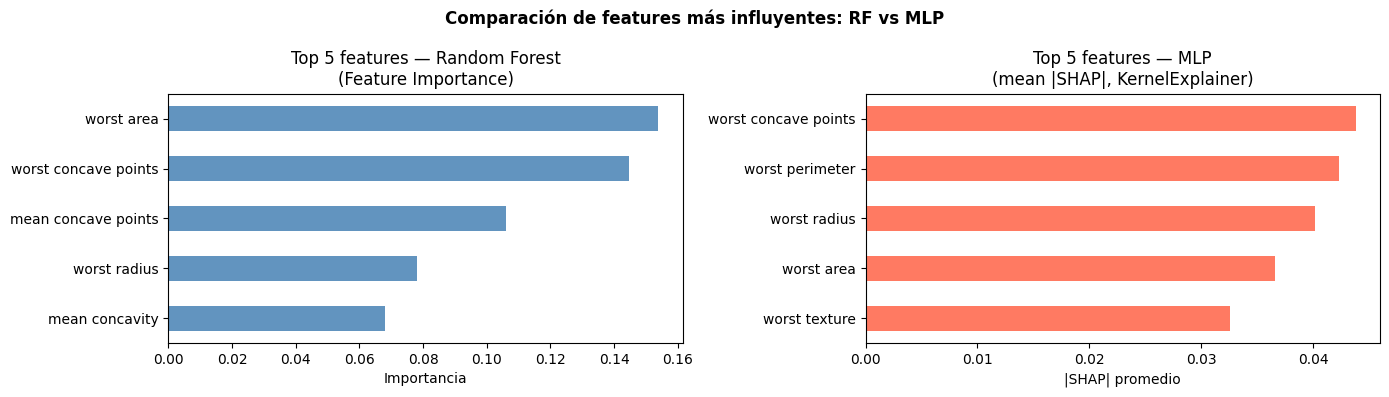

Features coincidentes en el top-5: 3/5 → worst concave points, worst area, worst radius
💡 Alta coincidencia → mayor confianza en que esas variables son genuinamente importantes.
⚠️  Baja coincidencia → los modelos aprendieron representaciones distintas; investigar cuál es más confiable.


In [10]:
# Comparación de features más influyentes: RF vs MLP
rf_top  = pd.Series(model.feature_importances_, index=features).nlargest(5)
mlp_top = pd.Series(np.abs(sv_nn1).mean(0), index=features).nlargest(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
rf_top[::-1].plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title('Top 5 features — Random Forest\n(Feature Importance)')
axes[0].set_xlabel('Importancia')

mlp_top[::-1].plot(kind='barh', ax=axes[1], color='tomato', alpha=0.85)
axes[1].set_title('Top 5 features — MLP\n(mean |SHAP|, KernelExplainer)')
axes[1].set_xlabel('|SHAP| promedio')

plt.suptitle('Comparación de features más influyentes: RF vs MLP', fontweight='bold')
plt.tight_layout()
plt.show()

common = set(rf_top.index) & set(mlp_top.index)
print(f'Features coincidentes en el top-5: {len(common)}/5 → {", ".join(common)}')
print('💡 Alta coincidencia → mayor confianza en que esas variables son genuinamente importantes.')
print('⚠️  Baja coincidencia → los modelos aprendieron representaciones distintas; investigar cuál es más confiable.')

## 8. Recomendaciones prácticas

| Aspecto | Recomendación |
|---------|---------------|
| **Feature Importance** | Usar como primera exploración rápida; solo disponible en modelos de árboles |
| **SHAP global** | Summary plot para entender qué features importan y en qué dirección |
| **SHAP local** | Waterfall plot para explicar predicciones individuales (más legible que force plot) |
| **SHAP Dependence** | Detectar interacciones no lineales entre features |
| **SHAP para NN** | `KernelExplainer` (universal) o `GradientExplainer` (más rápido, solo TF/PyTorch) |
| **LIME** | Preferir cuando el modelo es una caja negra sin acceso a gradientes |
| **Comparar RF vs MLP** | Si coinciden en top features, mayor confianza en la relevancia real |
| **Sesgos** | Buscar si features sensibles (género, raza) influyen en predicciones no deseadas |

> 💡 **Truco:** El **waterfall plot** de SHAP muestra la contribución de cada feature con valores numéricos exactos — `E[f(x)]` es el valor base (predicción promedio) y `f(x)` es la predicción final para la muestra.

> ⚠️ **KernelExplainer en producción:** Es lento (~1-10 min por lote). Para inferencia en tiempo real, entrena un modelo surrogate (árbol) sobre las predicciones del modelo original y aplica TreeExplainer.

## 9. Discusión y Conclusiones

**¿Qué aprendimos?**

- La **interpretabilidad** no es opcional en producción: es una herramienta de validación, auditoría y confianza.
- **SHAP TreeExplainer** es rápido y exacto para árboles, pero no aplica a redes neuronales.
- **SHAP KernelExplainer** funciona con cualquier modelo pero es ~100× más lento; se compensa evaluando un subconjunto de muestras.
- **SHAP GradientExplainer** es la alternativa rápida para redes TF/PyTorch (requiere acceso a gradientes).
- **LIME** es consistente entre RF y MLP para explicaciones locales; útil cuando SHAP no es compatible.
- La **comparación de features** entre RF y MLP reveló qué variables son robustamente relevantes independientemente de la arquitectura.
- Medir tiempos de SHAP vs LIME es clave para evaluar viabilidad en producción.

En el siguiente notebook exploraremos el **rendimiento de CPU vs GPU vs Metal** para deep learning.

## 10. Ejercicios Propuestos

1. **Ejercicio 1:** Aplica SHAP TreeExplainer a un GradientBoostingClassifier. ¿Coinciden las top features con el Random Forest?

2. **Ejercicio 2:** Compara las explicaciones LIME para una muestra **correctamente** clasificada y una **incorrectamente** clasificada. ¿Qué features causan el error?

3. **Ejercicio 3:** Usa `shap.GradientExplainer` en lugar de `KernelExplainer` para la red neuronal. ¿Cuánto más rápido es?

4. **Ejercicio 4 (Avanzado):** Implementa un **modelo surrogate**: entrena un árbol de decisión sobre las predicciones del MLP y aplica TreeExplainer. Compara con KernelExplainer en velocidad y coherencia de resultados.

## 9. Referencias y Recursos

- [Interpretable ML Book](https://christophm.github.io/interpretable-ml-book/)
- [SHAP Documentation](https://shap.readthedocs.io/)
- [LIME GitHub](https://github.com/marcotcr/lime)
- Lundberg & Lee (2017). *A Unified Approach to Interpreting Model Predictions.*

---

📎 **Notebook anterior:** [10. Clustering y Reducción](./10_clustering_reduccion_dimensionalidad.ipynb)  
📎 **Notebook siguiente:** [12. CPU, GPU y Metal](./12_cpu_gpu_metal.ipynb)